<a href="https://colab.research.google.com/github/write2chrischacko/Healthcare-Appointment-No-Show-Analysis-and-Prediction/blob/main/Model_Building_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Installing required & importing Libraries**

In [ ]:
# Install missing libraries first
!pip install imbalanced-learn xgboost shap --quiet

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns, warnings, shap
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from xgboost               import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats            import randint, uniform

plt.rcParams.update({'figure.facecolor':'white', 'axes.facecolor':'#f8f8f6',
    'axes.spines.top':False, 'axes.spines.right':False})
SEED = 42
print("All libraries loaded!")


All libraries loaded!


# **Upload & Load dataset**

In [ ]:
from google.colab import files
import io

uploaded = files.upload()   # click Choose Files → select CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Saving MedicalAppointment.csv to MedicalAppointment.csv
Shape: 110,527 rows × 14 columns


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


# **Feature Engineering- building strong predictors**

In [ ]:
# Parse dates
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Fix typo column names
df.rename(columns={'Hipertension':'Hypertension',
                   'Handcap':'Handicap', 'No-show':'NoShow'}, inplace=True)

# Target: 1 = no-show, 0 = showed up
df['target'] = (df['NoShow'] == 'Yes').astype(int)
df = df[df['Age'] >= 0].copy()

# lead_time: days between booking and appointment (strongest predictor)
df['lead_time'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['lead_time'] = df['lead_time'].clip(lower=0)

# prior_noshows: how many times this patient no-showed before THIS appointment
# Sort by date so we only count PAST no-shows, not future ones
df_s = df.sort_values('AppointmentDay')
df_s['prior_noshows'] = (
    df_s.groupby('PatientId')['target']
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)
df['prior_noshows'] = df_s['prior_noshows']

# day_of_week: 0=Monday … 5=Saturday
df['day_of_week'] = df['AppointmentDay'].dt.dayofweek

# appointment_month: seasonal pattern
df['appointment_month'] = df['AppointmentDay'].dt.month

# has_chronic: 1 if patient has any chronic condition
df['has_chronic'] = ((df['Hypertension'] + df['Diabetes'] + df['Alcoholism']) > 0).astype(int)

print("Features engineered successfully!")
df[['lead_time','prior_noshows','day_of_week','has_chronic']].head()

Features engineered successfully!


,lead_time,prior_noshows,day_of_week,has_chronic
0,0,0.0,4,1
1,0,0.0,4,0
2,0,0.0,4,0
3,0,0.0,4,0
4,0,0.0,4,1


# **Feature Selection - drop identifiers and encode categories**

In [ ]:
# Drop non-predictive identifier columns
DROP = ['PatientId','AppointmentID','ScheduledDay','AppointmentDay','NoShow']
df_model = df.drop(columns=DROP)

# Encode Gender: F→0, M→1
df_model['Gender'] = (df_model['Gender'] == 'M').astype(int)

# Neighbourhood: frequency encoding (map to no-show rate)
# This preserves geographic risk signal without 80+ dummy columns
neigh_rate = df_model.groupby('Neighbourhood')['target'].mean()
df_model['neighbourhood_risk'] = df_model['Neighbourhood'].map(neigh_rate)
df_model.drop(columns=['Neighbourhood'], inplace=True)

print("Final features:", df_model.drop(columns=['target']).columns.tolist())
print(f"Shape: {df_model.shape}")

Final features: ['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'lead_time', 'prior_noshows', 'day_of_week', 'appointment_month', 'has_chronic', 'neighbourhood_risk']
Shape: (110526, 15)


# **Test-Train-Split 80/20 stratified**

In [ ]:
X = df_model.drop(columns=['target'])
y = df_model['target']

# stratify=y → same 80/20 no-show class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"No-show rate in train: {y_train.mean():.2%}")
print(f"No-show rate in test : {y_test.mean():.2%}")

Training set : 88,420 rows
Test set     : 22,106 rows
No-show rate in train: 20.19%
No-show rate in test : 20.19%


# **Handle class imbalance - SMOTE**

Before SMOTE: {0: 70565, 1: 17855}
After SMOTE : {1: 70565, 0: 70565}
scale_pos_weight for XGBoost = 3.95


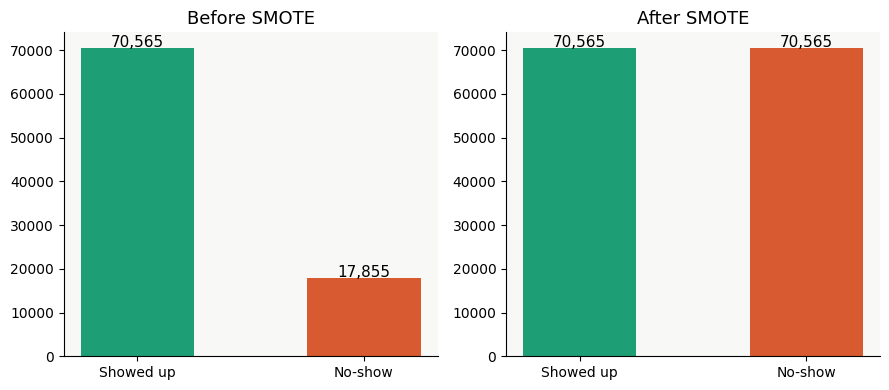

In [ ]:
# Apply SMOTE only to training data — test set stays untouched
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_sm).value_counts().to_dict())

# Compute scale_pos_weight for XGBoost
scale_pw = round((y_train==0).sum() / (y_train==1).sum(), 2)
print(f"scale_pos_weight for XGBoost = {scale_pw}")

# Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, (data, title) in zip(axes,[
    (y_train,    'Before SMOTE'),
    (y_train_sm, 'After SMOTE')
]):
    vc = pd.Series(data).value_counts()
    bars = ax.bar(['Showed up','No-show'],
                  [vc.get(0,0), vc.get(1,0)],
                  color=['#1D9E75','#D85A30'], width=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
               f"{int(bar.get_height()):,}", ha='center', fontsize=11)
    ax.set_title(title, fontsize=13)
plt.tight_layout(); plt.savefig('smote_balance.png',dpi=150,bbox_inches='tight')
plt.show()

# **Train all 4 models with reusable helper**

In [ ]:
# Reusable evaluation function
results_list = []
trained = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    row = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1-Score' : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba), 4),
    }
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Showed up','No-show']))
    trained[name] = model
    results_list.append(row)
    return model, y_pred, y_proba

# ── Model 1: Logistic Regression (baseline) ───────────────
lr_m, lr_pred, lr_prob = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    X_train_sm, y_train_sm, X_test, y_test
)


  Logistic Regression
              precision    recall  f1-score   support

   Showed up       0.85      0.66      0.74     17642
     No-show       0.28      0.54      0.37      4464

    accuracy                           0.63     22106
   macro avg       0.57      0.60      0.55     22106
weighted avg       0.73      0.63      0.66     22106



# **Train decision tree,random forest & XGBoost**

In [ ]:
# ── Model 2: Decision Tree ─────────────────────────────────────
dt_m, dt_pred, dt_prob = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                            class_weight='balanced', random_state=SEED),
    X_train_sm, y_train_sm, X_test, y_test
)

# ── Model 3: Random Forest ─────────────────────────────────────
rf_m, rf_pred, rf_prob = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=10,
                            min_samples_leaf=30, class_weight='balanced',
                            n_jobs=-1, random_state=SEED),
    X_train_sm, y_train_sm, X_test, y_test
)

# ── Model 4: XGBoost (main model) ──────────────────────────────
xgb_m, xgb_pred, xgb_prob = evaluate_model(
    'XGBoost',
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pw,   # handles imbalance natively
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=SEED
    ),
    X_train_sm, y_train_sm, X_test, y_test
)


  Decision Tree
              precision    recall  f1-score   support

   Showed up       0.89      0.61      0.72     17642
     No-show       0.31      0.69      0.43      4464

    accuracy                           0.63     22106
   macro avg       0.60      0.65      0.58     22106
weighted avg       0.77      0.63      0.66     22106


  Random Forest
              precision    recall  f1-score   support

   Showed up       0.88      0.66      0.76     17642
     No-show       0.33      0.64      0.43      4464

    accuracy                           0.66     22106
   macro avg       0.60      0.65      0.59     22106
weighted avg       0.77      0.66      0.69     22106


  XGBoost
              precision    recall  f1-score   support

   Showed up       0.94      0.42      0.58     17642
     No-show       0.28      0.88      0.42      4464

    accuracy                           0.52     22106
   macro avg       0.61      0.65      0.50     22106
weighted avg       0.80      

# **Evaluation-Confusion matrices+ROC+PR curve**

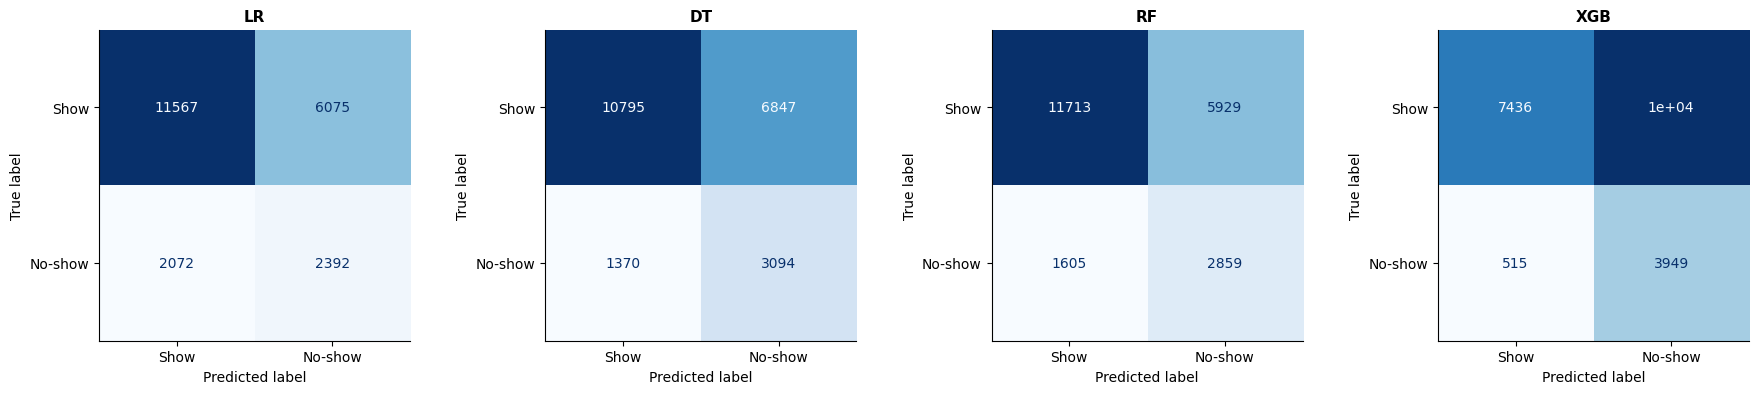

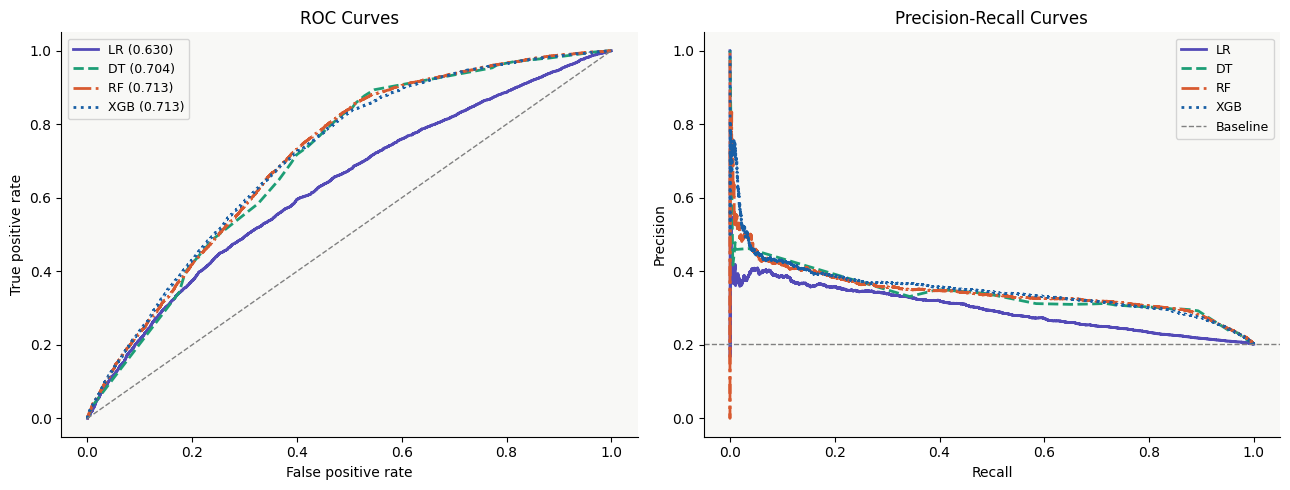

In [ ]:
pred_map  = {'LR':(lr_pred,lr_prob), 'DT':(dt_pred,dt_prob),
              'RF':(rf_pred,rf_prob), 'XGB':(xgb_pred,xgb_prob)}
colors4   = ['#534AB7','#1D9E75','#D85A30','#185FA5']
names4    = ['Logistic Regression','Decision Tree','Random Forest','XGBoost']

# Confusion matrices
fig, axes = plt.subplots(1,4,figsize=(18,4))
for ax,(name,(pred,_)) in zip(axes,pred_map.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm,display_labels=['Show','No-show']).plot(ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices.png',dpi=150,bbox_inches='tight')
plt.show()

# ROC + PR curves
fig, axes = plt.subplots(1,2,figsize=(13,5))
for (name,(_,prob)),color,ls in zip(pred_map.items(),colors4,['-','--','-.',':']):
    fpr,tpr,_ = roc_curve(y_test,prob); ra = auc(fpr,tpr)
    axes[0].plot(fpr,tpr,label=f'{name} ({ra:.3f})',color=color,ls=ls,lw=2)
    prec,rec,_ = precision_recall_curve(y_test,prob)
    axes[1].plot(rec,prec,label=name,color=color,ls=ls,lw=2)
axes[0].plot([0,1],[0,1],'gray',ls='--',lw=1)
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=9)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[1].axhline(y_test.mean(),color='gray',ls='--',lw=1,label='Baseline')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=9)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout(); plt.savefig('roc_pr_curves.png',dpi=150,bbox_inches='tight')
plt.show()

# **feature importance + SHAP**

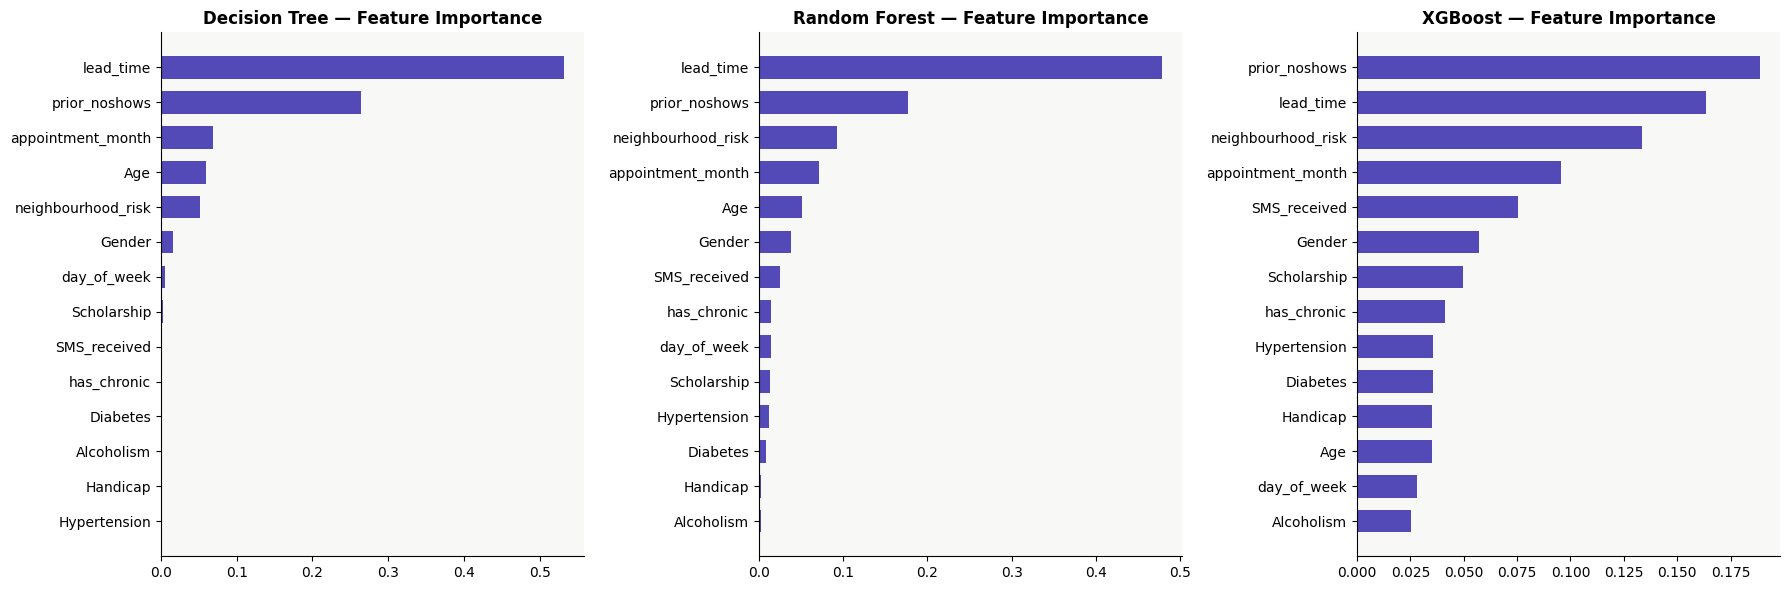

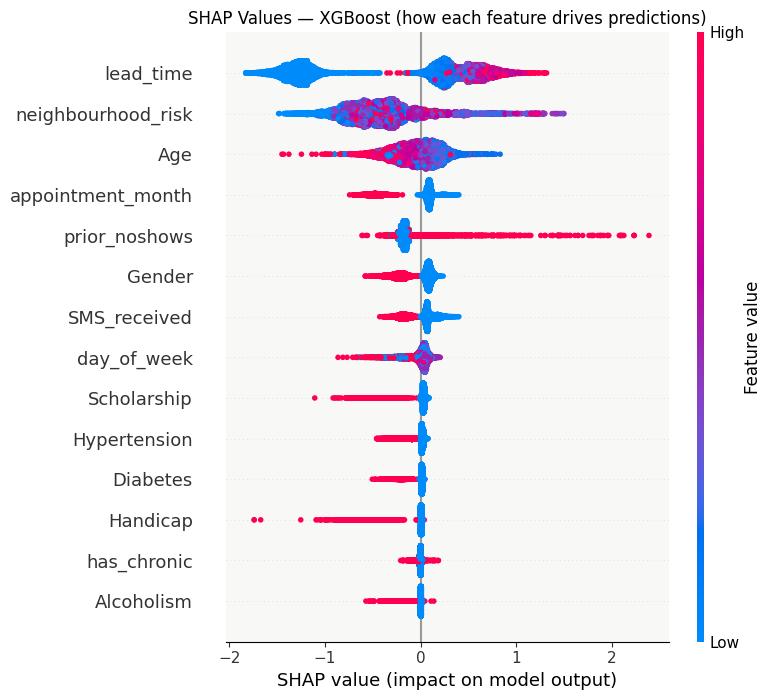

In [ ]:
feature_names = X_train.columns.tolist()

# Built-in feature importance (all 3 tree models)
fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax,(label,model) in zip(axes,[
    ('Decision Tree',  trained['Decision Tree']),
    ('Random Forest',  trained['Random Forest']),
    ('XGBoost',        trained['XGBoost']),
]):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    ax.barh(imp.index, imp.values, color='#534AB7', height=0.65)
    ax.set_title(f'{label} — Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance.png',dpi=150,bbox_inches='tight')
plt.show()

# SHAP summary plot for XGBoost (most explainable output)
shap.initjs()
explainer   = shap.TreeExplainer(trained['XGBoost'])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='dot', show=False)
plt.title('SHAP Values — XGBoost (how each feature drives predictions)', fontsize=12)
plt.tight_layout(); plt.savefig('shap_summary.png',dpi=150,bbox_inches='tight')
plt.show()

# **Hyperparameter tunning & Comparison**

In [ ]:
# GridSearchCV — Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    param_grid={'C':[0.01,0.1,1,10], 'penalty':['l1','l2'], 'solver':['liblinear']},
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_sm, y_train_sm)
print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best CV AUC   : {lr_grid.best_score_:.4f}")
lr_tuned_prob = lr_grid.predict_proba(X_test)[:,1]
lr_tuned_pred = lr_grid.predict(X_test)

# RandomizedSearchCV — XGBoost (30 random combinations)
xgb_rs = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pw, use_label_encoder=False,
                   eval_metric='logloss', random_state=SEED, n_jobs=-1),
    param_distributions={
        'n_estimators'    : randint(100,500),
        'max_depth'        : randint(3,10),
        'learning_rate'    : uniform(0.01,0.2),
        'subsample'        : uniform(0.6,0.4),
        'colsample_bytree' : uniform(0.6,0.4),
    },
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, random_state=SEED, verbose=1
)
xgb_rs.fit(X_train_sm, y_train_sm)
print(f"Best XGB params: {xgb_rs.best_params_}")
xgb_tuned_prob = xgb_rs.predict_proba(X_test)[:,1]
xgb_tuned_pred = xgb_rs.predict(X_test)

# Final comparison table
final = pd.DataFrame([
    {'Model':'LR baseline',   'AUC':roc_auc_score(y_test,lr_prob),        'F1':f1_score(y_test,lr_pred),        'Recall':recall_score(y_test,lr_pred)},
    {'Model':'LR tuned',      'AUC':roc_auc_score(y_test,lr_tuned_prob),  'F1':f1_score(y_test,lr_tuned_pred),  'Recall':recall_score(y_test,lr_tuned_pred)},
    {'Model':'Decision Tree', 'AUC':roc_auc_score(y_test,dt_prob),        'F1':f1_score(y_test,dt_pred),        'Recall':recall_score(y_test,dt_pred)},
    {'Model':'Random Forest', 'AUC':roc_auc_score(y_test,rf_prob),        'F1':f1_score(y_test,rf_pred),        'Recall':recall_score(y_test,rf_pred)},
    {'Model':'XGBoost',       'AUC':roc_auc_score(y_test,xgb_prob),       'F1':f1_score(y_test,xgb_pred),       'Recall':recall_score(y_test,xgb_pred)},
    {'Model':'XGB tuned',    'AUC':roc_auc_score(y_test,xgb_tuned_prob), 'F1':f1_score(y_test,xgb_tuned_pred), 'Recall':recall_score(y_test,xgb_tuned_pred)},
]).round(4)
print(final.to_string(index=False))
print(f"Best model: {final.loc[final['AUC'].idxmax(), 'Model']}")
print(f"Best AUC  : {final['AUC'].max():.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC   : 0.6904
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB params: {'colsample_bytree': np.float64(0.7257423924305306), 'learning_rate': np.float64(0.11171413823294056), 'max_depth': 8, 'n_estimators': 330, 'subsample': np.float64(0.7641531692142519)}
        Model    AUC     F1  Recall
  LR baseline 0.6296 0.3700  0.5358
     LR tuned 0.6299 0.3704  0.5341
Decision Tree 0.7036 0.4296  0.6931
Random Forest 0.7129 0.4315  0.6405
      XGBoost 0.7126 0.4242  0.8846
    XGB tuned 0.7066 0.4251  0.7885
Best model: Random Forest
Best AUC  : 0.7129
